# Import libraries

In [1]:
from pyrosetta import *
from utils import *
from pyrosetta.rosetta.protocols.grafting import delete_region

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.conda.ubuntu.cxx11thread.serialization.Ubuntu.python313.Release 2026.29+release.80a0635615099e1b918474a63acba7b1de6fd107 2026-07-14T16:24:11] retrieved from: http://www.pyrosetta.org


# Load and clean pdb file

In [3]:
# load pose
pose = pose_from_pdb('pdb_files/7K18.pdb')

# Ensure pdb file is correct
print(pose.sequence())
print(pose.residue(958).name())
print(len(pose.sequence()))

VRRAAVKILVHSLFSMLIMCTILTNCVFMAQHDPPPWTKYVEYTFTAIYTFESLVKILARGFCLHAFTFLRDPWNWLDFSVIVMAYTTEFVDGNVSALRTFRVLRALKTISVISGLKTIVGALIQSVKKLADVMVLTVFCLSVFALIGLQLFMGNLRHKCVRNFTELNGTNGSVEASLDVYLNDPANYLLKNGTTDVLLCGNSSDAGTCPEGYRCLKAGENPDHGYTSFDSFAWAFLALFRLMTQDCWERLYQQTLRSAGKIYMIFFMLVIFLGSFYLVNLILAVVAMAYEEQNQATECCPLWMSIKQKVKFVVMDPFADLTITMCIVLNTLFMALEHYNMTAEFEEMLQVGNLVFTGIFTAEMTFKIIALDPYYYFQQGWNIFDSIIVILSLMELGSVLRSFRLLRVFKLAKSWPTLNTLIKIIGNSVGALGNLTLVLAIIVFIFAVVGMQLFGKNYSELRHRISDSGLLPRWHMMDFFHAFLIIFRILCGEWIETMWDCMEVSGQSLCLLVFLLVMVIGNLVVLNLFLALLLSSFGKVWWRLRKTCYRIVEHSWFETFIIFMILLSSGALAFEDIYLEERKTIKVLLEYADKMFTYVFVLEMLLKWVAYGFKKYFTNAWCWLDFLIVDVSLVSLVANTLGFAEMGPIKSLRTLRALRPLRALSRFEGMRVVVNALVGAIPSIMNVLLVCLIFWLIFSIMGVNLFAGKFGRCINQTEGDLPLNYTIVNNKSECESFNVTGELYWTKVKVNFDNVGAGYLALLQVATFKGWMDIMYAAVDSRGYEEQPQWEDNLYMYIYFVVFIIFGSFFTLNLFIGVIIDNFNQQKKKLGGQDIFMTEEQKKYYNAMKKLGSKKPQKPIPRPLNKYQGFIFDIVTKQAFDVTIMFLICLNMVTMMVETDDQSPEKVNILAKINLLFVAIFTGECIVKMAALRHYYFTNSWNIFDFVVVILSIVGTVLSDIIQKYFFSPTLFRVIRLARIGRILRLIRGAKGIRTLLFAL

In [4]:
# Shorten pose to region we are interested in
trunc_pose = Pose()
trunc_pose.assign(pose)
delete_region(trunc_pose,1,899)
delete_region(trunc_pose,101,229)

# Ensure new pose is correct
print(trunc_pose.sequence())
print(f'Original length: {len(pose.sequence())} New length: {len(trunc_pose.sequence())}')

DDQSPEKVNILAKINLLFVAIFTGECIVKMAALRHYYFTNSWNIFDFVVVILSIVGTVLSDIIQKYFFSPTLFRVIRLARIGRILRLIRGAKGIRTLLFAVRDGYIAQPENCVYHCFPGSSGCDTLCKEKGGTSGHCGFKVGHGLACWCNALPDNVGIIVEGEKCHS
Original length: 1195 New length: 167


In [5]:
# Relax structure
relaxedpose = relax_structure(trunc_pose)

# saved relax structure
dump_pdb(relaxedpose, 'pdb_files/7K18_relaxed.pdb')

Relaxed energy: -281.63527772084365


True

# Exploration

[Jiang et al. (2021)](https://www.nature.com/articles/s41467-020-20078-3) determined the structure of LQHIII-NaV1.5 complex utilizing electron microscopy. The researchers proposed that Asp1612 on NaV1.5 plays a key role in binding the LQHIII scorpion toxin. In the native complex, two histidine residues on LQHIII act as molecular "pinchers," forming hydrogen bonds and a salt bridge with Asp1612. This interaction is illustrated in the figure below.

![Caption](Images/7K18_NaV1.5_LQHIII_complex.png)

In this section I will explore other parts of this complex important for this interaction. 

Protein_A residues : 100
Protein_B residues   : 67


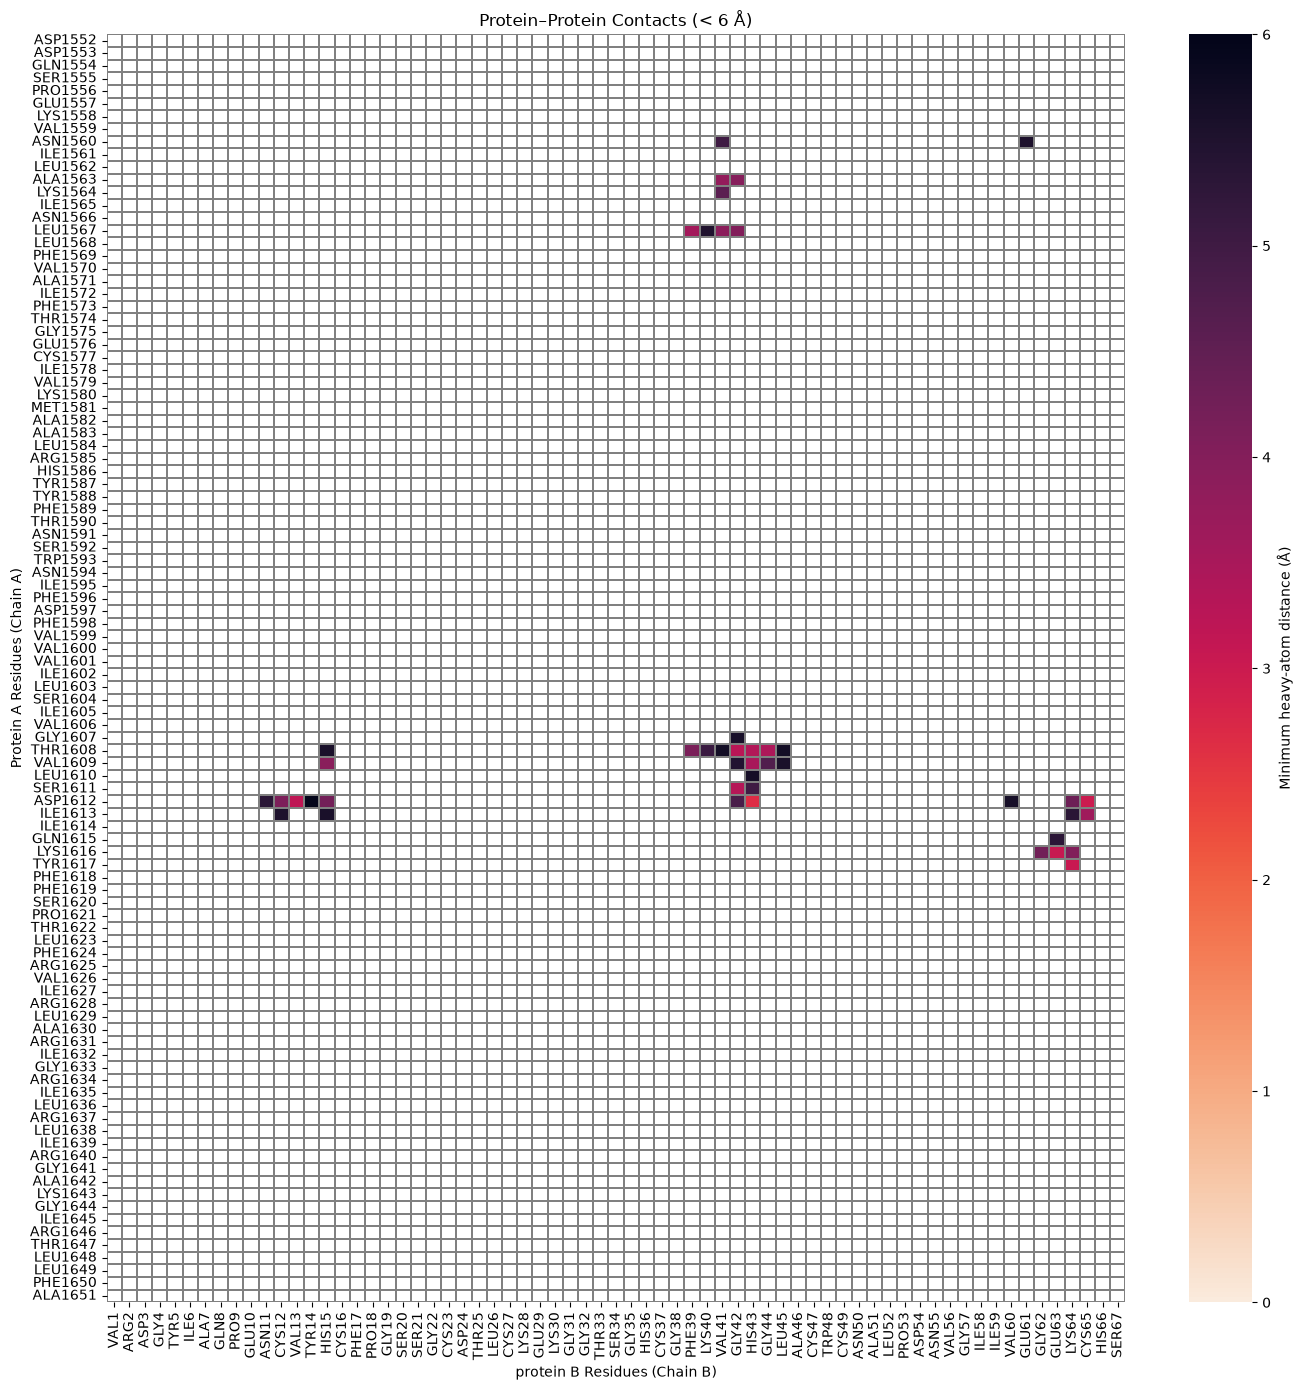

In [6]:
contact_map('pdb_files/7K18_relaxed.pdb', 6, 'Data/7K18.png')

In [2]:
alanine_scanner('pdb_files/7K18_relaxed.pdb', 6)

Protein_A residues : 100
Protein_B residues   : 67
[[64, 65, 8, 11, 12, 15, 55, 56, 57, 58, 59, 60, 61, 63], [64, 38, 39, 40, 41, 42, 43, 44, 10, 14, 11, 12, 13, 59, 60, 61, 62, 63]]
{64, 65, 8, 11, 12, 15, 55, 56, 57, 58, 59, 60, 61, 63}
{64, 38, 39, 40, 41, 42, 43, 44, 10, 14, 11, 12, 13, 59, 60, 61, 62, 63}
[64, 65, 8, 11, 12, 15, 55, 56, 57, 58, 59, 60, 61, 63]
K 64
Y 65

--------------------------------------------------
TASK COMPLETE
Successfully mutated LYS at position 65 to ALA
Orginal Energy -278.5991913744625; New energy: -273.15503017360766
--------------------------------------------------


Y 65
F 66

--------------------------------------------------
TASK COMPLETE
Successfully mutated TYR at position 66 to ALA
Orginal Energy -278.5991913744625; New energy: -276.16559034697684
--------------------------------------------------


N 8
I 9

--------------------------------------------------
TASK COMPLETE
Successfully mutated ASN at position 9 to ALA
Orginal Energy -278.599191

,ddG_binding,chain_num,AA
1616,0.850074,1,K
1617,1.663317,1,Y
1560,0.021503,1,N
1563,0.0,1,A
1564,-0.055886,1,K
1567,3.405841,1,L
1607,-0.0,1,G
1608,1.96786,1,T
1609,1.238922,1,V
1610,0.0,1,L


![Caption](Images/con.png)
![Caption](Images/Conservation_LQHIII.png)